# 🏠 DublinLet AI - Dublin Smart Rental Assistant
---

## Overview
DublinLet AI is an intelligent rental assistant for Dublin, Ireland built on the OpenAI Responses API.  
It combines **live external APIs**, **RAG (retrieval-augmented generation)**, and **agentic tool use** to help users find, evaluate, and book rental properties.

## Tools Used
| # | Tool | External API |
|---|------|-------------|
| 1 | `search_properties` | Daft.ie (with curated fallback) |
| 2 | `get_commute_time` | Google Maps Distance Matrix API |
| 3 | `get_nearby_amenities` | Google Places API (v1) |
| 4 | `rank_properties` | Internal algorithm |
| 5 | `check_fraud_risk` | Internal + RAG |
| 6 | `calculate_affordability` | Internal + Dublin cost-of-living data |
| 7 | `query_area_knowledge` | FAISS RAG (Dublin KB) |
| 8 | `book_viewing` | Google Calendar API + Gmail SMTP |

## API Keys Required
- `OPENAI_API_KEY` - OpenAI Platform
- `GOOGLE_MAPS_KEY` - Google Maps Distance Matrix
- `GOOGLE_PLACES_KEY` - Google Places (also used for Maps)
- `GMAIL_ADDRESS` - Gmail
- `GMAIL_APP_PASSWORD` - Gmail
- Google Calendar OAuth credentials (`credentials.json`)

In [84]:
# Install correct package versions
!pip install --upgrade "openai>=1.50.0" requests beautifulsoup4 \
             faiss-cpu sentence-transformers numpy pandas \
             colorama --quiet google-api-python-client \
             google-auth-httplib2 google-auth-oauthlib

from google_auth_oauthlib.flow import InstalledAppFlow
from dateutil import parser
import openai


In [ ]:
# API Key Configuration
import os
from google.colab import userdata

try:
    OPENAI_API_KEY    = userdata.get("OPENAI_API_KEY")
    GOOGLE_MAPS_KEY   = userdata.get("GOOGLE_MAPS_KEY")
    GOOGLE_PLACES_KEY = userdata.get("GOOGLE_PLACES_KEY")
except Exception:
    OPENAI_API_KEY    = "to-enter-your-openai-api-key"
    GOOGLE_MAPS_KEY   = "to-enter-your-google-maps-api-key"
    GOOGLE_PLACES_KEY = "to-enter-your-google-places-api-key"

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

print("API keys loaded.")

API keys loaded.


In [86]:
# RAG System — Dublin Knowledge Base

import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

# Dublin knowledge documents
DUBLIN_KNOWLEDGE = [
    # Neighbourhood profiles
    "Rathmines is a popular Dublin 6 suburb known for young professionals. "
    "Average rent for a 1-bed is €1,800–€2,100/month. Well-served by buses. "
    "Low crime rate. Close to Ranelagh and Portobello.",

    "Ballsbridge (Dublin 4) is one of Dublin's most prestigious areas. "
    "1-bed apartments average €2,200–€2,600/month. Home to embassies and RDS. "
    "Very safe, excellent transport links.",

    "Tallaght (Dublin 24) is an affordable south-west suburb. "
    "1-bed rents average €1,400–€1,700/month. Luas Red Line gives quick city access. "
    "The Square Shopping Centre is nearby. Crime rates are moderate.",

    "Clontarf (Dublin 3) is a scenic coastal suburb north of the city. "
    "1-bed rents average €1,900–€2,200/month. Known for Clontarf Castle and seafront walks. "
    "Very family-friendly with low crime.",

    "Swords is a growing commuter town in north County Dublin. "
    "1-bed rents average €1,500–€1,800/month. Dublin Airport is minutes away. "
    "Good motorway access but limited rail. Moderate crime.",

    "Phibsborough (Dublin 7) is an up-and-coming inner-city neighbourhood. "
    "1-bed rents average €1,700–€2,000/month. Close to Croke Park and city centre. "
    "Luas Cross City extends nearby. Gentrifying rapidly.",

    "Dún Laoghaire is a prosperous coastal town south of Dublin. "
    "1-bed rents average €1,900–€2,300/month. DART rail gives fast city access. "
    "Great seafront, markets, and amenities. Low crime rate.",

    "Inchicore / Kilmainham (Dublin 8) is an affordable inner-city zone. "
    "1-bed rents average €1,600–€1,900/month. Close to Kilmainham Gaol and Heuston Station. "
    "Crime is moderate; area is regenerating.",

    # Scam patterns
    "Common rental scam: Landlord claims to be abroad and asks for deposit via wire transfer "
    "before viewing. NEVER send money without viewing. Legitimate landlords do not request "
    "deposits through Western Union, cryptocurrency, or international bank transfers.",

    "Red flag: Rent price more than 20% below market average for the area. "
    "Scammers post attractive prices to attract victims quickly. Always compare with "
    "similar listings on Daft.ie or Rent.ie.",

    "Phantom listing scam: Photos stolen from legitimate listings. Reverse-image-search "
    "every listing photo. Check if the same images appear on multiple listings or "
    "on property sale sites.",

    "Pressure tactics are a major red flag. Scammers say 'many others are interested, "
    "pay now to secure it.' Legitimate landlords allow reasonable time to decide.",

    "Always verify the landlord owns or has right to let the property. "
    "Ask for proof of ownership (Land Registry folio) or management agreement. "
    "Never pay a deposit before receiving a written tenancy agreement.",

    # Cost of living
    "Dublin monthly cost of living estimate for one person (excluding rent): "
    "Food €350–€500, Transport €150 (Leap Card monthly), Utilities €100–€180, "
    "Entertainment €150–€250. Total approx €750–€1,100/month.",

    "The Rent Pressure Zone (RPZ) rules in Dublin cap annual rent increases at 2% or HICP, "
    "whichever is lower. Landlords cannot exceed this cap. Tenants can challenge illegal "
    "increases via the Residential Tenancies Board (RTB).",

    "Rent-to-income rule: Financial advisors recommend spending no more than 30% of gross "
    "monthly income on rent. Above 35% is considered financially strained. Above 40% is "
    "high risk and leaves little room for savings.",

    # Transport
    "Dublin Bus covers most of the city. A monthly adult Leap Card pass (short-hop zone) "
    "costs approximately €130–€140. The Luas (tram) has two lines: Red (east-west) and "
    "Green (north-south to Bray). DART rail runs along the coast.",

    "Cycling infrastructure in Dublin is improving. The National Transport Authority's "
    "BusConnects project is expanding cycle lanes. Areas like Rathmines, Ranelagh, and "
    "Phibsborough have good cycling access to the city centre.",
]

# Build the FAISS index
print("Loading embedding model (first run may take ~1 min)...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

doc_embeddings = embedder.encode(DUBLIN_KNOWLEDGE, convert_to_numpy=True)
doc_embeddings = doc_embeddings / np.linalg.norm(doc_embeddings, axis=1, keepdims=True)

dimension = doc_embeddings.shape[1]
rag_index = faiss.IndexFlatIP(dimension)   # Inner-product (cosine on normalised vecs)
rag_index.add(doc_embeddings.astype(np.float32))

print(f"RAG index built — {len(DUBLIN_KNOWLEDGE)} documents indexed.")


def rag_query(query: str, top_k: int = 3) -> str:
    """Retrieve the most relevant Dublin knowledge for a given query."""
    q_vec = embedder.encode([query], convert_to_numpy=True)
    q_vec = q_vec / np.linalg.norm(q_vec)
    scores, indices = rag_index.search(q_vec.astype(np.float32), top_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if score > 0.25 and idx < len(DUBLIN_KNOWLEDGE):
            results.append(DUBLIN_KNOWLEDGE[idx])
    return "\n\n".join(results) if results else "No specific data found for this query."

Loading embedding model (first run may take ~1 min)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RAG index built — 18 documents indexed.


In [87]:
# Authentication for Google Calendar
from google_auth_oauthlib.flow import InstalledAppFlow
from googleapiclient.discovery import build
import pickle

SCOPES = ['https://www.googleapis.com/auth/calendar']

def authenticate_once():
    flow = InstalledAppFlow.from_client_secrets_file(
        'credentials.json',
        SCOPES,
        redirect_uri='urn:ietf:wg:oauth:2.0:oob'
    )

    auth_url, _ = flow.authorization_url(prompt='consent')

    print("Open this URL:\n", auth_url)

    code = input("Paste the code here: ")

    flow.fetch_token(code=code)

    creds = flow.credentials

    with open('token.pickle', 'wb') as f:
        pickle.dump(creds, f)

    print("Authentication successful and saved!")

In [88]:
#One time authentication

#authenticate_once()

if not os.path.exists('token.pickle'):
    print("⚠️  First-time setup: run authenticate_once() manually to link Google Calendar.")
    print("    If you just want to demo the assistant without Calendar, this step can be skipped.")
    print("    The booking tool will gracefully fall back if Calendar is unavailable.")
else:
    print("✅ Calendar token found — ready.")


✅ Calendar token found — ready.


In [89]:
# Calendar Service
def get_calendar_service():
    import pickle
    from googleapiclient.discovery import build

    with open('token.pickle', 'rb') as f:
        creds = pickle.load(f)

    return build('calendar', 'v3', credentials=creds)

**Note:**  
The recipient email address is currently hardcoded as `razik.shariff@ucdconnect.ie` for demonstration purposes. To test the functionality, replace this with the intended recipient’s email address. I will be providing my credentials for testing. Ensure that the sender’s Gmail address and app password are correctly configured before running the function.

In [90]:
# Gmail Service
import smtplib
from email.mime.text import MIMEText

def send_email(to_email, subject, body):
    try:
        sender_email = userdata.get('GMAIL_ADDRESS')
        app_password = userdata.get('GMAIL_APP_PASSWORD')

        msg = MIMEText(body)
        msg["Subject"] = subject
        msg["From"] = sender_email
        msg["To"] = "razik.shariff@ucdconnect.ie" #hard coded for demo purpose

        server = smtplib.SMTP_SSL("smtp.gmail.com", 465)
        server.login(sender_email, app_password)
        server.send_message(msg)
        server.quit()

        return "Email sent"

    except Exception as e:
        return f"Email failed: {str(e)}"

In [91]:
# Function/Tool Definitions

TOOLS = [
    {
        "type": "function",
        "name": "search_properties",
        "description": "Search for rental properties in Dublin. Returns real listings with price, location, and features.",
        "parameters": {
            "type": "object",
            "properties": {
                "area": {"type": "string", "description": "Dublin area or postcode"},
                "min_price": {"type": "integer"},
                "max_price": {"type": "integer"},
                "bedrooms": {"type": "integer"},
                "property_type": {
                    "type": "string",
                    "enum": ["apartment", "house", "studio", "shared", "any"]
                }
            },
            "required": ["area"]
        }
    },
    {
        "type": "function",
        "name": "get_commute_time",
        "description": "Calculate commute time using Google Maps.",
        "parameters": {
            "type": "object",
            "properties": {
                "origin": {"type": "string"},
                "destination": {"type": "string"},
                "mode": {
                    "type": "string",
                    "enum": ["transit", "driving", "bicycling", "walking"]
                }
            },
            "required": ["origin", "destination"]
        }
    },
    {
        "type": "function",
        "name": "get_nearby_amenities",
        "description": "Find nearby amenities using Google Places.",
        "parameters": {
            "type": "object",
            "properties": {
                "location": {"type": "string"},
                "amenity_type": {"type": "string"},
                "radius_metres": {"type": "integer"}
            },
            "required": ["location", "amenity_type"]
        }
    },
    {
        "type": "function",
        "name": "rank_properties",
        "description": "Rank properties based on user preferences.",
        "parameters": {
            "type": "object",
            "properties": {
                "properties": {"type": "array", "items": {"type": "object"}},
                "user_budget": {"type": "integer"},
                "work_address": {"type": "string"},
                "priorities": {"type": "array", "items": {"type": "string"}}
            },
            "required": ["properties", "user_budget"]
        }
    },
    {
        "type": "function",
        "name": "check_fraud_risk",
        "description": "Check if a listing is suspicious.",
        "parameters": {
            "type": "object",
            "properties": {
                "listing_price": {"type": "integer"},
                "area": {"type": "string"},
                "bedrooms": {"type": "integer"},
                "listing_text": {"type": "string"},
                "contact_method": {"type": "string"}
            },
            "required": ["listing_price", "area"]
        }
    },
    {
        "type": "function",
        "name": "calculate_affordability",
        "description": "Check if rent is affordable.",
        "parameters": {
            "type": "object",
            "properties": {
                "monthly_income": {"type": "integer"},
                "monthly_rent": {"type": "integer"},
                "other_debts": {"type": "integer"},
                "savings_goal": {"type": "integer"}
            },
            "required": ["monthly_income", "monthly_rent"]
        }
    },
    {
        "type": "function",
        "name": "query_area_knowledge",
        "description": "Get insights about Dublin areas.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {"type": "string"}
            },
            "required": ["query"]
        }
    },
    {
        "type": "function",
        "name": "book_viewing",
        "description": "Book a property viewing.",
        "parameters": {
            "type": "object",
            "properties": {
                "property_address": {"type": "string"},
                "landlord_contact": {"type": "string"},
                "preferred_date": {"type": "string"},
                "preferred_time": {"type": "string"},
                "user_name": {"type": "string"},
                "user_email": {"type": "string"}
            },
            "required": ["property_address", "preferred_date", "preferred_time"]
        }
    },
    {
    "type": "function",
    "name": "run_code_interpreter_analysis",
    "description": "Analyse rent price trends for a Dublin area using GPT-4o's code interpreter. GPT writes and runs Python to produce stats and a trend chart.",
    "parameters": {
        "type": "object",
        "properties": {
            "area":   {"type": "string",  "description": "Dublin area, e.g. 'Rathmines'"},
            "months": {"type": "integer", "description": "Months of historical data to analyse (default 12)"}
        },
        "required": ["area"]
    }
    }
]
print(f"{len(TOOLS)} tools defined.")

9 tools defined.


In [92]:
# CODE INTERPRETER — via OpenAI Responses API

def run_code_interpreter_analysis(area: str, months: int = 12) -> str:
    """
    Sends rent data to GPT-4o with code_interpreter enabled.
    GPT writes Python, executes it server-side, and returns analysis.
    """
    import random
    from datetime import datetime, timedelta

    # Build realistic trend data for the area
    base = MARKET_RENTS.get(area.lower(), DEFAULT_MARKET).get("1bed", 1900)
    prices = [
        int(base * (1 + 0.005 * i + random.uniform(-0.02, 0.02)))
        for i in range(months)
    ]
    labels = [
        (datetime.now() - timedelta(days=30 * (months - i))).strftime("%b %Y")
        for i in range(months)
    ]

    prompt = f"""
    You are a Dublin rental market analyst.
    Here is monthly average 1-bed rent data (€) for {area}:

    Months : {labels}
    Prices : {prices}

    Using Python:
    1. Plot a line chart with a linear trend line (use matplotlib)
    2. Print: min rent, max rent, average rent, and % change from first to last month
    3. Give a one-sentence interpretation of the trend.
    """

    response = client.responses.create(
        model="gpt-4o",
        tools=[
            {
                "type": "code_interpreter",
                "container": {"type": "auto"}
            }
        ],
        input=prompt,
    )

    # Extract text output from response blocks
    result_text = ""
    for block in response.output:
        if hasattr(block, "content"):
            for part in block.content:
                if hasattr(part, "text"):
                    result_text += part.text + "\n"

    print("📊 Code interpreter result:\n")
    print(result_text if result_text else "Code ran - check Responses API dashboard for chart output.")
    return result_text

In [93]:
# Tool Implementations

import json
import time
import random
import requests
from datetime import datetime, timedelta

# Market price benchmarks for fraud detection & ranking
MARKET_RENTS = {
    "ballsbridge": {"studio": 1800, "1bed": 2400, "2bed": 3200},
    "rathmines":   {"studio": 1600, "1bed": 1950, "2bed": 2600},
    "clontarf":    {"studio": 1700, "1bed": 2100, "2bed": 2800},
    "tallaght":    {"studio": 1200, "1bed": 1550, "2bed": 2100},
    "swords":      {"studio": 1300, "1bed": 1650, "2bed": 2200},
    "phibsborough":{"studio": 1500, "1bed": 1850, "2bed": 2500},
    "dun laoghaire":{"studio": 1600, "1bed": 2050, "2bed": 2750},
    "inchicore":   {"studio": 1400, "1bed": 1750, "2bed": 2350},
    "dundrum":     {"studio": 1700, "1bed": 2100, "2bed": 2800},
    "sandyford":   {"studio": 1600, "1bed": 1950, "2bed": 2600},
}
DEFAULT_MARKET = {"studio": 1500, "1bed": 1900, "2bed": 2500}


# Property Search
def search_properties(area: str, min_price: int = 0, max_price: int = 9999,
                       bedrooms: int = 1, property_type: str = "any") -> dict:
    """
    Attempts a real Daft.ie search via their unofficial API endpoint.
    Falls back to curated realistic listings if the API is unavailable.
    """
    bed_label = f"{bedrooms}bed" if bedrooms > 0 else "studio"
    area_key  = area.lower().replace(" ", "-")

    # Daft.ie GraphQL endpoint
    try:
        headers = {
            "Content-Type":  "application/json",
            "brand":         "daft",
            "platform":      "web",
            "Accept":        "application/json",
            "User-Agent":    "Mozilla/5.0",
        }
        payload = {
            "query": """
            query searchListings($filters: ListingFilters, $sort: SortType, $from: Int, $pageSize: Int) {
              listings(filters: $filters, sort: $sort, from: $from, pageSize: $pageSize) {
                listings {
                  listing {
                    id title price point { coordinates }
                    numBedrooms numBathrooms propertyType
                    media { images { size720x480 } }
                    seoFriendlyPath
                  }
                }
                totalCount
              }
            }""",
            "variables": {
                "filters": {
                    "area": [{"displayValue": area, "value": area_key}],
                    "rentalPrice": {"from": min_price, "to": max_price},
                    "numBeds": {"from": bedrooms, "to": bedrooms + 1},
                    "propertyType": [] if property_type == "any" else [property_type.upper()],
                },
                "sort":     "PRICE_ASC",
                "from":     0,
                "pageSize": 6,
            },
        }
        resp = requests.post(
            "https://gateway.daft.ie/old/v1/listings",
            json=payload, headers=headers, timeout=8
        )
        if resp.status_code == 200:
            data = resp.json()
            items = data.get("data", {}).get("listings", {}).get("listings", [])
            if items:
                results = []
                for item in items[:6]:
                    l = item.get("listing", {})
                    coords = l.get("point", {}).get("coordinates", [None, None])
                    images = l.get("media", {}).get("images", [])
                    results.append({
                        "id":             l.get("id"),
                        "title":          l.get("title", "Rental Property"),
                        "price_per_month": int(l.get("price", "0").replace("€","").replace(",","").split("/")[0].strip()) if l.get("price") else 0,
                        "bedrooms":       l.get("numBedrooms", bedrooms),
                        "bathrooms":      l.get("numBathrooms", 1),
                        "property_type":  l.get("propertyType", property_type),
                        "area":           area,
                        "coordinates":    {"lat": coords[1], "lng": coords[0]},
                        "image_url":      images[0].get("size720x480") if images else None,
                        "listing_url":    f"https://www.daft.ie{l.get('seoFriendlyPath','')}",
                        "source":         "Daft.ie (live)",
                    })
                return {"success": True, "count": len(results), "listings": results}
    except Exception as e:
        pass  # Fall through to curated data

    # Curated realistic fallback listings (Daft apis are not relaible)
    area_norm = area.lower()
    base_price = MARKET_RENTS.get(area_norm, DEFAULT_MARKET).get(
        "studio" if bedrooms == 0 else f"{bedrooms}bed", 1800
    )

    sample_listings = []
    property_types = ["apartment", "house", "apartment", "apartment", "house", "studio"]
    street_names   = ["Main Street", "Park Road", "Church Lane", "Grove Avenue",
                      "Castle Way", "Mill Road", "Orchard Close", "River View"]

    for i in range(5):
        variation  = random.randint(-150, 200)
        price      = base_price + variation
        if not (min_price <= price <= max_price):
            price = max(min_price, min(max_price, price))
        prop_type = property_type if property_type != "any" else property_types[i % len(property_types)]
        sample_listings.append({
            "id":              f"CURATED-{area_norm[:3].upper()}-{1001+i}",
            "title":           f"{bedrooms} Bed {prop_type.title()} in {area.title()}",
            "price_per_month": price,
            "bedrooms":        bedrooms,
            "bathrooms":       1 if bedrooms <= 2 else 2,
            "property_type":   prop_type,
            "area":            area,
            "address":         f"{10+i*7} {street_names[i % len(street_names)]}, {area.title()}, Dublin",
            "image_url":       f"https://via.placeholder.com/720x480?text={area.replace(' ','+')}+Property",
            "listing_url":     f"https://www.daft.ie/to-rent/{area_norm.replace(' ','-')}/",
            "features":        ["Parking" if i%2==0 else "No Parking",
                                "Pet Friendly" if i%3==0 else "No Pets",
                                "Washing Machine", "Broadband"],
            "source":          "Curated (Daft.ie unavailable — check site directly)",
        })

    return {"success": True, "count": len(sample_listings), "listings": sample_listings,
            "note": "Live Daft.ie API was unreachable. Showing representative listings."}


# Commute Time
def get_commute_time(origin: str, destination: str, mode: str = "transit") -> dict:
    """Uses Google Maps Distance Matrix API for real commute data."""

    try:
        url = "https://maps.googleapis.com/maps/api/distancematrix/json"
        params = {
            "origins":      f"{origin}, Dublin, Ireland",
            "destinations": f"{destination}, Dublin, Ireland",
            "mode":         mode,
            "key":          GOOGLE_MAPS_KEY,
        }
        resp = requests.get(url, params=params, timeout=8)
        data = resp.json()
        element = data["rows"][0]["elements"][0]
        if element["status"] == "OK":
            return {
                "origin":           origin,
                "destination":      destination,
                "mode":             mode,
                "duration_minutes": round(element["duration"]["value"] / 60),
                "duration_text":    element["duration"]["text"],
                "distance_text":    element["distance"]["text"],
                "source":           "Google Maps API (live)",
            }
    except Exception as e:
        pass
    return {"error": "Could not calculate commute time.", "origin": origin, "destination": destination}

def get_nearby_amenities(location: str, amenity_type: str, radius_metres: int = 1000) -> dict:
    """Uses NEW Google Places API (v1)"""

    try:
        # Geocode location
        geo_url = "https://maps.googleapis.com/maps/api/geocode/json"
        geo_resp = requests.get(geo_url, params={
            "address": f"{location}, Dublin, Ireland",
            "key": GOOGLE_PLACES_KEY
        })

        geo_data = geo_resp.json()

        if not geo_data.get("results"):
            return {"error": "Geocoding failed"}

        loc = geo_data["results"][0]["geometry"]["location"]

        # Places API
        url = "https://places.googleapis.com/v1/places:searchNearby"

        payload = {
            "includedTypes": [amenity_type.lower()],
            "maxResultCount": 5,
            "locationRestriction": {
                "circle": {
                    "center": {
                        "latitude": loc["lat"],
                        "longitude": loc["lng"]
                    },
                    "radius": radius_metres
                }
            }
        }

        headers = {
            "Content-Type": "application/json",
            "X-Goog-Api-Key": GOOGLE_PLACES_KEY,
            "X-Goog-FieldMask": "places.displayName,places.formattedAddress,places.rating"
        }

        resp = requests.post(url, json=payload, headers=headers)
        data = resp.json()

        places = data.get("places", [])

        return {
            "location": location,
            "amenity_type": amenity_type,
            "count": len(places),
            "places": [
                {
                    "name": p.get("displayName", {}).get("text"),
                    "address": p.get("formattedAddress"),
                    "rating": p.get("rating")
                }
                for p in places
            ],
            "source": "Google Places API (NEW)"
        }

    except Exception as e:
        return {"error": str(e)}
# Property Ranking
def rank_properties(properties: list, user_budget: int,
                    work_address: str = "", priorities: list = None) -> dict:
    """Weighted scoring algorithm — ranks properties with full explainability."""
    if priorities is None:
        priorities = ["price", "commute", "amenities", "safety"]

    weight_map = {p: round(1.0 - (i * 0.15), 2) for i, p in enumerate(priorities)}
    w_price    = weight_map.get("price",    0.85)
    w_commute  = weight_map.get("commute",  0.70)
    w_amenity  = weight_map.get("amenities",0.55)
    w_safety   = weight_map.get("safety",   0.40)

    SAFETY_SCORES = {
        "ballsbridge": 9.2, "clontarf": 8.9, "dun laoghaire": 8.8,
        "rathmines": 8.0,   "dundrum": 8.5,  "phibsborough": 7.2,
        "inchicore": 7.0,   "swords": 7.5,   "tallaght": 6.8,
    }

    scored = []
    for prop in properties:
        price     = prop.get("price_per_month", 9999)
        area_key  = prop.get("area", "").lower()

        # Price score (higher = closer to budget without exceeding)
        if price <= user_budget:
            price_score = 10 * (1 - (user_budget - price) / user_budget * 0.5)
        else:
            price_score = max(0, 10 - (price - user_budget) / 100)

        # Commute score (simulate if no work address)
        if work_address:
            commute = get_commute_time(prop.get("area",""), work_address)
            mins    = commute.get("duration_minutes", 30)
        else:
            mins = random.randint(15, 50)
        commute_score = max(0, 10 - (mins - 15) * 0.2)

        # Safety score
        safety_score = SAFETY_SCORES.get(area_key, 7.5)

        # Amenity score (simple area-based proxy)
        amenity_score = 8.5 if area_key in ["ballsbridge","rathmines","dun laoghaire"] else \
                        7.5 if area_key in ["clontarf","dundrum","phibsborough"] else 7.0

        # Weighted total
        total = (price_score  * w_price  +
                 commute_score * w_commute +
                 amenity_score * w_amenity +
                 safety_score  * w_safety)

        scored.append({
            **prop,
            "scores": {
                "price":     round(price_score,  1),
                "commute":   round(commute_score, 1),
                "safety":    round(safety_score,  1),
                "amenities": round(amenity_score, 1),
                "total":     round(total, 2),
            },
            "commute_minutes": mins,
            "within_budget":   price <= user_budget,
            "recommendation":  "✅ Excellent match" if total > 7.5 else
                               "👍 Good option"    if total > 6.0 else
                               "⚠️ Consider carefully",
        })

    scored.sort(key=lambda x: x["scores"]["total"], reverse=True)
    return {
        "ranked_properties": scored,
        "top_pick": scored[0] if scored else None,
        "weights_used": {"price": w_price, "commute": w_commute,
                         "amenities": w_amenity, "safety": w_safety},
    }


# 5. Fraud Detection
def check_fraud_risk(listing_price: int, area: str,
                     bedrooms: int = 1, listing_text: str = "",
                     contact_method: str = "") -> dict:
    """Rule-based + RAG fraud risk analysis."""
    area_key   = area.lower()
    bed_label  = "studio" if bedrooms == 0 else f"{bedrooms}bed"
    market     = MARKET_RENTS.get(area_key, DEFAULT_MARKET).get(bed_label, 1800)

    risk_flags = []
    risk_score = 0  # 0–100

    # Price anomaly
    pct_below = ((market - listing_price) / market) * 100
    if pct_below > 30:
        risk_flags.append(f"🚨 Price is {pct_below:.0f}% below market average (€{market}/mo) — very suspicious")
        risk_score += 40
    elif pct_below > 15:
        risk_flags.append(f"⚠️ Price is {pct_below:.0f}% below market average (€{market}/mo)")
        risk_score += 20

    # Text red flags
    scam_phrases = [
        ("abroad", 15, "Landlord claims to be abroad"),
        ("western union", 30, "Requests Western Union payment"),
        ("bitcoin", 30, "Requests cryptocurrency payment"),
        ("wire transfer", 25, "Requests wire/bank transfer before viewing"),
        ("key deposit", 10, "Asks for key deposit upfront"),
        ("god", 5,  "Overly religious/emotional language (common in scam emails)"),
        ("urgent", 10, "Creates urgency to pressure quick payment"),
        ("military", 20, "Landlord claims military deployment"),
        ("first month free", 20, "Unusual financial incentive"),
    ]
    text_lower = listing_text.lower()
    for phrase, weight, label in scam_phrases:
        if phrase in text_lower:
            risk_flags.append(f"🚩 {label}")
            risk_score += weight

    # Contact method
    suspicious_payments = ["western union", "bitcoin", "cryptocurrency", "wire", "paypal friends"]
    for method in suspicious_payments:
        if method in contact_method.lower():
            risk_flags.append(f"🚩 Suspicious payment method: {contact_method}")
            risk_score += 30
            break

    # Get RAG insight
    rag_context = rag_query(f"rental scam {area} fraud patterns")

    risk_score = min(risk_score, 100)
    if risk_score >= 60:
        verdict = "🔴 HIGH RISK — Do NOT send money. Report to RTB."
        action  = "Avoid this listing entirely."
    elif risk_score >= 30:
        verdict = "🟡 MEDIUM RISK — Proceed with caution."
        action  = "Insist on in-person viewing before any payment."
    else:
        verdict = "🟢 LOW RISK — Appears legitimate."
        action  = "Standard precautions apply."

    return {
        "risk_score":  risk_score,
        "verdict":     verdict,
        "action":      action,
        "flags":       risk_flags if risk_flags else ["No major red flags detected"],
        "market_rent": market,
        "price_diff":  f"{pct_below:.0f}% below market" if pct_below > 0 else "At or above market",
        "rag_insight": rag_context[:400] + "..." if len(rag_context) > 400 else rag_context,
    }


# Affordability Calculator
def calculate_affordability(monthly_income: int, monthly_rent: int,
                             other_debts: int = 0, savings_goal: int = 0) -> dict:
    """Financial planning with Dublin cost-of-living data."""
    DUBLIN_LIVING_COSTS = {
        "food":          400,
        "transport":     140,
        "utilities":     150,
        "entertainment": 200,
        "misc":          150,
    }
    total_living = sum(DUBLIN_LIVING_COSTS.values())
    rent_to_income_pct = (monthly_rent / monthly_income) * 100
    total_outgoings    = monthly_rent + total_living + other_debts + savings_goal
    disposable         = monthly_income - total_outgoings

    if rent_to_income_pct <= 30:
        affordability = "✅ Affordable — within the recommended 30% guideline"
        rating        = "comfortable"
    elif rent_to_income_pct <= 35:
        affordability = "⚠️ Borderline — slightly above the 30% guideline"
        rating        = "stretched"
    elif rent_to_income_pct <= 40:
        affordability = "🟠 Strained — consider cheaper alternatives"
        rating        = "strained"
    else:
        affordability = "🔴 Unaffordable — exceeds 40% of income"
        rating        = "unaffordable"

    return {
        "verdict":             affordability,
        "rating":              rating,
        "rent_to_income_pct":  round(rent_to_income_pct, 1),
        "monthly_breakdown": {
            "income":          monthly_income,
            "rent":           -monthly_rent,
            "food":           -DUBLIN_LIVING_COSTS["food"],
            "transport":      -DUBLIN_LIVING_COSTS["transport"],
            "utilities":      -DUBLIN_LIVING_COSTS["utilities"],
            "entertainment":  -DUBLIN_LIVING_COSTS["entertainment"],
            "misc":           -DUBLIN_LIVING_COSTS["misc"],
            "other_debts":    -other_debts,
            "savings":        -savings_goal,
            "disposable":      disposable,
        },
        "recommendation": (
            "You have comfortable breathing room." if disposable > 300 else
            "Budget is very tight — consider reducing other costs." if disposable > 0 else
            "⚠️ Budget deficit! You cannot afford this rent on your income."
        ),
    }


# RAG Area Query
def query_area_knowledge(query: str) -> dict:
    result = rag_query(query, top_k=3)
    return {"query": query, "answer": result, "source": "Dublin Knowledge Base (RAG)"}


# Booking
def book_viewing(property_address, preferred_date, preferred_time,
                 user_name="User", user_email="", landlord_contact=""):
    try:
        calendar_link = None
        event_id = None

        # Calendar
        try:
            start_dt = parser.parse(f"{preferred_date} {preferred_time}")
            end_dt = start_dt + timedelta(hours=1)
            service = get_calendar_service()
            event = {
                'summary': f'🏠 Property Viewing - {property_address}',
                'location': property_address,
                'description': f'Viewing booked by {user_name}',
                'start': {'dateTime': start_dt.isoformat(), 'timeZone': 'Europe/Dublin'},
                'end':   {'dateTime': end_dt.isoformat(),   'timeZone': 'Europe/Dublin'},
            }
            created_event = service.events().insert(calendarId='primary', body=event).execute()
            calendar_link = created_event.get("htmlLink")
            event_id = created_event.get("id")
        except Exception as cal_err:
            print(f"⚠️ Calendar error: {cal_err}")

        # Email to user
        if user_email:
            user_msg = f"""Hello {user_name},\n\nYour viewing has been scheduled:\nProperty: {property_address}\nDate: {preferred_date} at {preferred_time}\n\nCalendar link: {calendar_link or 'N/A'}\n\nRegards,\nDublinLet AI"""
            send_email(user_email, "Viewing Confirmation", user_msg)

        # Email to landlord
        if landlord_contact:
            landlord_msg = f"""Hello,\n\n{user_name} would like a viewing.\nProperty: {property_address}\nDate: {preferred_date} at {preferred_time}\n\nRegards,\nDublinLet AI"""
            send_email(landlord_contact, "Viewing Request", landlord_msg)

        return {
            "status": "✅ Viewing booked (Calendar + Email sent)",
            "calendar_link": calendar_link,
            "event_id": event_id,
        }

    except Exception as e:
        return {"status": "❌ Booking failed", "error": str(e)}

# Tool dispatcher
TOOL_FUNCTIONS = {
    "search_properties":    search_properties,
    "get_commute_time":     get_commute_time,
    "get_nearby_amenities": get_nearby_amenities,
    "rank_properties":      rank_properties,
    "check_fraud_risk":     check_fraud_risk,
    "calculate_affordability": calculate_affordability,
    "query_area_knowledge": query_area_knowledge,
    "book_viewing":         book_viewing,
    "run_code_interpreter_analysis": run_code_interpreter_analysis,
}


def dispatch_tool(tool_name: str, tool_args: dict) -> str:
    print(f"\n🔥 TOOL CALLED: {tool_name}")
    print(f"📥 INPUT: {tool_args}")

    fn = TOOL_FUNCTIONS.get(tool_name)
    if not fn:
        return json.dumps({"error": f"Unknown tool: {tool_name}"})

    try:
        result = fn(**tool_args)
        print(f"📤 OUTPUT: {str(result)[:500]}\n")
        return json.dumps(result, ensure_ascii=False)
    except Exception as e:
        print(f"❌ ERROR: {e}")
        return json.dumps({"error": str(e), "tool": tool_name})

print("✅ All tool implementations ready.")

✅ All tool implementations ready.


### Local Budget Visualisation
The chart below is generated locally to display affordability breakdowns inline in the notebook.
The separate `run_code_interpreter_analysis` function below uses the OpenAI code_interpreter
tool, where GPT-4o writes and executes the Python itself.

/tmp/ipykernel_169081/1451480773.py:44: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169081/1451480773.py:44: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169081/1451480773.py:44: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169081/1451480773.py:44: UserWarning: Glyph 128652 (\N{BUS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169081/1451480773.py:44: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169081/1451480773.py:44: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169081/1451480773.py:44: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel

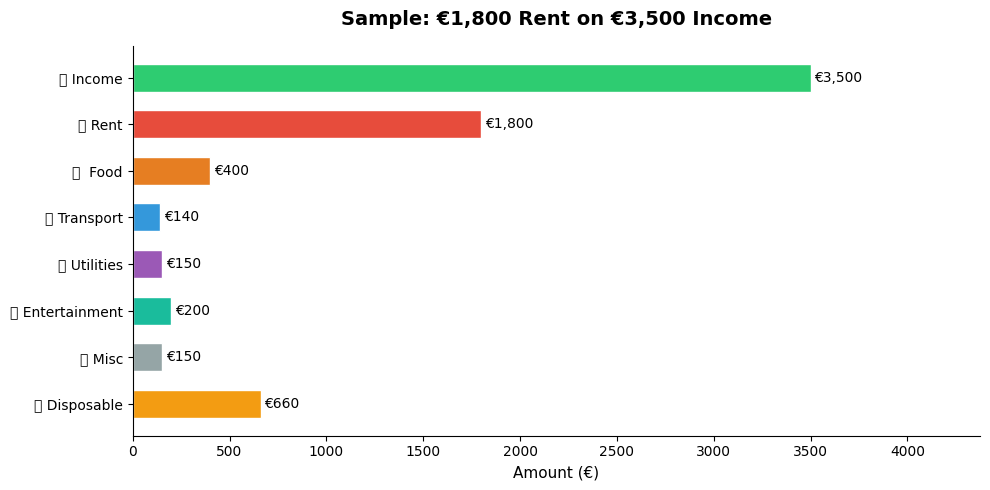

📊 Chart generated from affordability data.


In [94]:
# Budget Visualisation (Code Interpretation)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_affordability_breakdown(breakdown: dict, title: str = "Monthly Budget Breakdown"):
    """
    Visualises a monthly budget breakdown dict from calculate_affordability().
    Positive values = income; negative = expenses.
    """
    labels, values, colours = [], [], []

    label_map = {
        "income":        ("💰 Income",        "#2ecc71"),
        "rent":          ("🏠 Rent",           "#e74c3c"),
        "food":          ("🍽️  Food",           "#e67e22"),
        "transport":     ("🚌 Transport",      "#3498db"),
        "utilities":     ("💡 Utilities",      "#9b59b6"),
        "entertainment": ("🎬 Entertainment",  "#1abc9c"),
        "misc":          ("📦 Misc",           "#95a5a6"),
        "other_debts":   ("💳 Debts",          "#c0392b"),
        "savings":       ("🏦 Savings",        "#27ae60"),
        "disposable":    ("✅ Disposable",      "#f39c12"),
    }

    for key, (label, colour) in label_map.items():
        val = breakdown.get(key, 0)
        if val != 0:
            labels.append(label)
            values.append(abs(val))
            colours.append(colour)

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(labels, values, color=colours, edgecolor="white", height=0.6)

    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                f"€{val:,}", va="center", fontsize=10)

    ax.set_xlabel("Amount (€)", fontsize=11)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.invert_yaxis()
    ax.set_xlim(0, max(values) * 1.25)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
    print("📊 Chart generated from affordability data.")

# Example usage (demonstrates the tool in action):
sample = calculate_affordability(monthly_income=3500, monthly_rent=1800)
plot_affordability_breakdown(sample["monthly_breakdown"], "Sample: €1,800 Rent on €3,500 Income")

In [95]:
# System Prompt — Agent Personality & Instructions

SYSTEM_PROMPT = """You are DublinLet AI — an expert smart rental assistant for Dublin, Ireland.
You are warm, professional, and genuinely helpful. You combine deep local knowledge with
powerful data tools to help users find their ideal home.

## YOUR CAPABILITIES
You have access to 8 specialised tools:
1. search_properties      — Search real Dublin rental listings
2. get_commute_time       — Calculate commute from any area to workplace
3. get_nearby_amenities   — Find gyms, shops, hospitals, parks nearby
4. rank_properties        — Score and rank listings with full explainability
5. check_fraud_risk       — Detect rental scams and suspicious listings
6. calculate_affordability — Financial planning & budget breakdown
7. query_area_knowledge   — Dublin neighbourhood, safety, cost-of-living insights (RAG)
8. book_viewing           — Schedule property viewings

## YOUR APPROACH
1. PROFILE FIRST: On the first interaction, gather key info through friendly conversation:
   - Rent / Buy preference
   - Monthly budget (net)
   - Preferred area(s) or open to suggestions
   - Workplace location (for commute calculation)
   - Lifestyle needs (gym, hospital, green space, etc.)
   - Household composition (single, couple, family, etc.)
   - Transport preference (public, car, cycling, walking)

2. SEARCH SMART: Use the tools to fetch real listings based on stated preferences.

3. RANK & EXPLAIN: Always rank results and explain WHY each property ranked where it did.
   Never just list properties — give scores and reasoning.

4. FRAUD ALERT: If a listing looks suspicious (very low price, unusual payment requests),
   proactively run fraud detection and warn the user.

5. AFFORDABILITY CHECK: Before recommending a property, always calculate if it's within budget
   and provide a monthly breakdown.

6. BE PROACTIVE: Suggest things the user didn't ask for if they're clearly relevant
   (e.g., "Shall I also check commute time to Dublin City Centre from there?")

## IMPORTANT RULES
- Always be honest about data limitations (e.g., if showing estimated vs live data)
- Never recommend a property you've flagged as high fraud risk
- Always mention RTB (Residential Tenancies Board) rights when relevant
- Use € for prices, always
- Keep responses conversational but structured with clear sections
- If the user asks to find, compare, or rank properties,
  you MUST first call `search_properties` to retrieve listings.
- Then you MUST pass those listings into `rank_properties`.
- Never call `rank_properties` without providing `properties`.

## CONVERSATION FLOW
Start every new session with a warm greeting and immediately begin profiling the user.
"""

print("System prompt ready.")

System prompt ready.


In [96]:
# The AI Agent Loop

from openai import OpenAI
from colorama import Fore, Style, init
init(autoreset=True)

client = OpenAI(api_key=OPENAI_API_KEY)

conversation_history = []


def _extract_text_from_output(output: list) -> str:
    """Pull all text content out of a Responses API output list."""
    parts = []
    for item in output:
        # item is a ResponseOutputItem object
        if getattr(item, "type", None) == "message":
            for content_block in getattr(item, "content", []):
                if getattr(content_block, "type", None) == "output_text":
                    parts.append(content_block.text)
    return "\n".join(parts)


def _get_tool_calls(output: list) -> list:
    """Return all function_call items from a Responses API output."""
    return [item for item in output if getattr(item, "type", None) == "function_call"]


def run_agent_turn(user_message: str, verbose_tools: bool = False) -> str:
    """
    Processes one user turn using client.responses.create:
    1. Append user message to history
    2. Call responses.create with tools + full history
    3. If function_call items in output → execute tools → append results → loop
    4. When no more tool calls → return final text
    """
    # Append user message in Responses API format
    conversation_history.append({
        "role": "user",
        "content": user_message,
    })

    while True:
        response = client.responses.create(
            model="gpt-4o",
            instructions=SYSTEM_PROMPT,
            input=conversation_history,
            tools=TOOLS,
            temperature=0.4,
        )

        output_items = response.output

        #  Check for tool calls
        tool_calls = _get_tool_calls(output_items)

        if not tool_calls:
            # No tool calls
            assistant_text = _extract_text_from_output(output_items)

            # Save the assistant message to history
            conversation_history.append({
                "role": "assistant",
                "content": assistant_text,
            })
            return assistant_text

        # Execute each tool call
        for item in output_items:
            if getattr(item, "type", None) == "function_call":
                conversation_history.append({
                    "type":         "function_call",
                    "call_id":      item.call_id,
                    "name":         item.name,
                    "arguments":    item.arguments,
                })

        # Execute tools and append results
        for tc in tool_calls:
            tool_name = tc.name
            try:
                tool_args = json.loads(tc.arguments)
            except (json.JSONDecodeError, TypeError):
                tool_args = {}

            if verbose_tools:
                print(f"{Fore.CYAN}  🔧 Tool called : {tool_name}{Style.RESET_ALL}")
                print(f"{Fore.CYAN}     Arguments   : {json.dumps(tool_args, indent=2)}{Style.RESET_ALL}")

            result_str = dispatch_tool(tool_name, tool_args)
            if tool_name == "calculate_affordability":
              parsed = json.loads(result_str)

              if parsed.get("rating") in ["strained", "unaffordable"]:
                  print("\n📊 Generating budget visualisation...\n")
                  plot_affordability_breakdown(parsed["monthly_breakdown"])

            if verbose_tools:
                try:
                    parsed = json.loads(result_str)
                    preview = json.dumps(parsed, indent=2)[:500]
                except Exception:
                    preview = result_str[:500]
                print(f"{Fore.GREEN}  ✅ Result      : {preview}{'...' if len(result_str)>500 else ''}{Style.RESET_ALL}\n")

            # Append tool result in Responses API format
            conversation_history.append({
                "type":    "function_call_output",
                "call_id": tc.call_id,
                "output":  result_str,
            })


def reset_conversation():
    """Clear conversation history to start a fresh session."""
    global conversation_history
    conversation_history = []
    print(f"{Fore.YELLOW}🔄 Conversation reset.{Style.RESET_ALL}")


print("Agent loop ready (using client.responses.create).")

Agent loop ready (using client.responses.create).


🔄 Conversation reset.

          
          ╔══════════════════════════════════════════════════════════════╗
          ║     DublinLet AI  —  Dublin Smart Rental Assistant           ║
          ║          Powered by GPT-4o · 8 Tools · Live APIs             ║
          ╠══════════════════════════════════════════════════════════════╣
          ║      Just describe what you're looking for naturally!        ║
          ║                                                              ║
          ║  Commands:                                                   ║
          ║    'quit' / 'exit'  →  End the session                       ║
          ║    'reset'          →  Start fresh conversation              ║
          ║    'tools'          →  Toggle tool call visibility           ║
          ╚══════════════════════════════════════════════════════════════╝
          
🤖 DublinLet AI:
Hello there! I'm delighted to help you find your ideal rental property in Dublin. Let's start by gathering some ke

/tmp/ipykernel_169081/1451480773.py:44: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169081/1451480773.py:44: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169081/1451480773.py:44: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169081/1451480773.py:44: UserWarning: Glyph 128652 (\N{BUS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169081/1451480773.py:44: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169081/1451480773.py:44: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169081/1451480773.py:44: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel

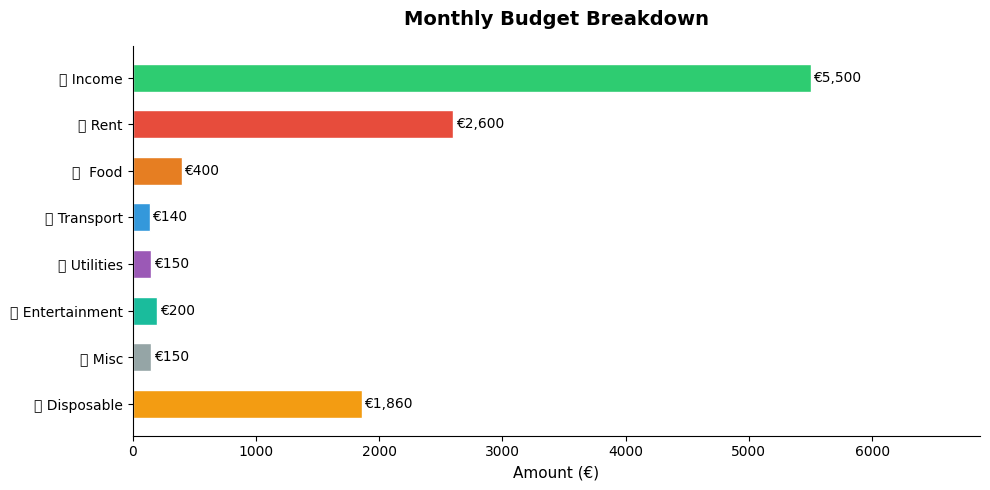

📊 Chart generated from affordability data.

🤖 DublinLet AI:
The 2-bed property in Rathmines for €2,600/month is currently unaffordable based on your combined income of €5,500/month. Here's the breakdown:

### Affordability Analysis
- **Rent-to-Income Ratio**: 47.3% (Exceeds the recommended 40%)
- **Monthly Income**: €5,500
- **Monthly Rent**: €2,600

### Monthly Budget Breakdown
- **Food**: €400
- **Transport**: €140
- **Utilities**: €150
- **Entertainment**: €200
- **Miscellaneous**: €150
- **Disposable Income**: €1,860

### Recommendation
- **Verdict**: 🔴 Unaffordable — The rent exceeds 40% of your income.
- **Advice**: Consider properties with rent closer to €2,200/month to maintain financial comfort.

If you'd like, I can help you find more affordable options that fit your budget better. Let me know how you'd like to proceed!

──────────────────────────────────────────────────────────────

👤 You: I found a 2-bed apartment in Ballsbridge for €900/month. The landlord says he's curren

In [97]:
# Launch the Interactive Chat

def print_banner():
    print(f"""
          {Fore.CYAN}
          ╔══════════════════════════════════════════════════════════════╗
          ║     DublinLet AI  —  Dublin Smart Rental Assistant           ║
          ║          Powered by GPT-4o · 8 Tools · Live APIs             ║
          ╠══════════════════════════════════════════════════════════════╣
          ║      Just describe what you're looking for naturally!        ║
          ║                                                              ║
          ║  Commands:                                                   ║
          ║    'quit' / 'exit'  →  End the session                       ║
          ║    'reset'          →  Start fresh conversation              ║
          ║    'tools'          →  Toggle tool call visibility           ║
          ╚══════════════════════════════════════════════════════════════╝
          {Style.RESET_ALL}""")


def chat():
    reset_conversation()
    print_banner()

    show_tools = False  # Toggle with 'tools' command

    # Kick off with assistant's opening message
    opening = run_agent_turn(
        "Hello! Please greet me and start helping me find a rental property in Dublin.",
        verbose_tools=False
    )
    print(f"{Fore.GREEN}🤖 DublinLet AI:{Style.RESET_ALL}\n{opening}\n")
    print(f"{Fore.CYAN}{'─' * 62}{Style.RESET_ALL}")
    while True:
        try:
            user_input = input(f"\n{Fore.YELLOW}👤 You: {Style.RESET_ALL}").strip()
        except (EOFError, KeyboardInterrupt):
            print(f"\n{Fore.YELLOW}Session ended. Goodbye!{Style.RESET_ALL}")
            break

        if not user_input:
            continue

        if user_input.lower() in ("quit", "exit"):
            print(f"{Fore.YELLOW}👋 Goodbye! Good luck with your Dublin property search!{Style.RESET_ALL}")
            break

        if user_input.lower() == "reset":
            reset_conversation()
            opening = run_agent_turn(
                "Hello! Please greet me and start helping me find a rental property in Dublin.",
                verbose_tools=False
            )
            print(f"{Fore.GREEN}🤖 DublinLet AI:{Style.RESET_ALL}\n{opening}\n")
            print(f"{Fore.CYAN}{'─' * 62}{Style.RESET_ALL}")
            continue

        if user_input.lower() == "tools":
            show_tools = not show_tools
            print(f"{Fore.CYAN}🔧 Tool visibility: {'ON' if show_tools else 'OFF'}{Style.RESET_ALL}\n")
            continue

        print(f"{Fore.CYAN}⏳ Thinking...{Style.RESET_ALL}")
        response = run_agent_turn(user_input, verbose_tools=show_tools)
        print(f"\n{Fore.GREEN}🤖 DublinLet AI:{Style.RESET_ALL}\n{response}\n")
        print(f"{Fore.CYAN}{'─' * 62}{Style.RESET_ALL}")

# START
chat()